In [2]:
import pandas as pd
import numpy as np

In [6]:
df_full = pd.read_csv("data/full_survey_data_recoded.csv")
df_full.head(20)

,QKEY,DEVICE_TYPE_W49,LANG_W49,FORM_W49,SOCMEDIAUSEa_W49,SOCMEDIAUSEb_W49,SOCMEDIAUSEc_W49,SOCMEDIAUSEd_W49,SNSUSER_W49,ELECTFTGSNSINT_W49,...,FACE3a_W49_num,FACE3b_W49_num,FACE3c_W49_num,FACE4a_W49_num,FACE4b_W49_num,FACE4c_W49_num,FACE4d_W49_num,DB1a_W49_num,DB1b_W49_num,DB1c_W49_num
0,100260.0,Tablet,English,Form 2,"No, do not use this","No, do not use this","No, do not use this","No, do not use this",Does not use social media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,100588.0,Mobile phone,English,Form 1,"Yes, use this","Yes, use this","Yes, use this","No, do not use this",Social media user,I am worn out by how many political posts and ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
2,100637.0,Desktop,English,Form 1,"Yes, use this","No, do not use this","No, do not use this","No, do not use this",Social media user,I am worn out by how many political posts and ...,...,0.0,0.0,2.0,1.0,1.0,NaN,NaN,1.0,0.0,0.0
3,101224.0,Mobile phone,English,Form 2,"Yes, use this","No, do not use this","No, do not use this","No, do not use this",Social media user,I am worn out by how many political posts and ...,...,0.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0
4,101322.0,Mobile phone,English,Form 1,"Yes, use this","No, do not use this","No, do not use this","No, do not use this",Social media user,I am worn out by how many political posts and ...,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
5,101437.0,Desktop,English,Form 2,"Yes, use this","No, do not use this","No, do not use this","No, do not use this",Social media user,I don’t feel strongly about these posts one wa...,...,1.0,1.0,3.0,NaN,NaN,NaN,1.0,0.0,0.0,0.0
6,101472.0,Mobile phone,English,Form 1,"Yes, use this","No, do not use this","Yes, use this","No, do not use this",Social media user,I am worn out by how many political posts and ...,...,1.0,1.0,2.0,1.0,1.0,NaN,NaN,0.0,0.0,0.0
7,101493.0,Desktop,English,Form 1,"Yes, use this","No, do not use this","No, do not use this","Yes, use this",Social media user,I am worn out by how many political posts and ...,...,0.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,0.0
8,102198.0,Mobile phone,English,Form 1,"Yes, use this","Yes, use this","No, do not use this","Yes, use this",Social media user,I am worn out by how many political posts and ...,...,1.0,2.0,3.0,1.0,0.0,NaN,NaN,0.0,0.0,0.0
9,103094.0,Mobile phone,English,Form 1,"Yes, use this","Yes, use this","Yes, use this","Yes, use this",Social media user,I am worn out by how many political posts and ...,...,0.0,0.0,0.0,NaN,0.0,NaN,NaN,0.0,0.0,1.0


In [25]:
targets = [
    "TRACKGOV1a_W49_num", "TRACKGOV1b_W49_num", "CONCERNGOV_W49_num", "BENEFITGOV_W49_num",
    "CONTROLGOV_W49_num", "UNDERSTANDGOV_W49_num", "POSNEGGOV_W49_num", "ANONYMOUS1GOV_W49_num",
    "CONCERNGRPd_W49_num", "CONCERNGRPf_W49_num", "PP5a_W49_num", "PP5b_W49_num", "PP5c_W49_num", "PP5d_W49_num", "PP5e_W49_num", "PP6a_W49_num", "PP6b_W49_num", "PP6c_W49_num", "SHARE1_W49_num", "PROFILE1_W49_num"
]

# Add 'QKEY' to the list of columns to keep
cols_to_keep = ["QKEY"] + targets

# Keep only those columns
df_targets = df_full[cols_to_keep]



In [51]:
import pandas as pd

government = [
    "TRACKGOV1a_W49_num", "TRACKGOV1b_W49_num", "CONCERNGOV_W49_num",
    "BENEFITGOV_W49_num", "CONTROLGOV_W49_num", "UNDERSTANDGOV_W49_num",
    "POSNEGGOV_W49_num", "ANONYMOUS1GOV_W49_num"
]

company = [
    "CONCERNGRPd_W49_num", "CONCERNGRPf_W49_num", "PP5a_W49_num",
    "PP5b_W49_num", "PP5c_W49_num", "PP5d_W49_num", "PP5e_W49_num",
    "PP6a_W49_num", "PP6b_W49_num", "PP6c_W49_num", "SHARE1_W49_num",
    "PROFILE1_W49_num"
]

# Compute Spearman correlations
corr = df_targets[government + company].corr(method='spearman')

# Extract only the government–company block
corr_block_gov_com = corr.loc[government, company]
corr_block_gov_gov = corr.loc[government, government]
corr_block_com_com = corr.loc[company, company]
corr_block_all = corr.loc[targets, targets]


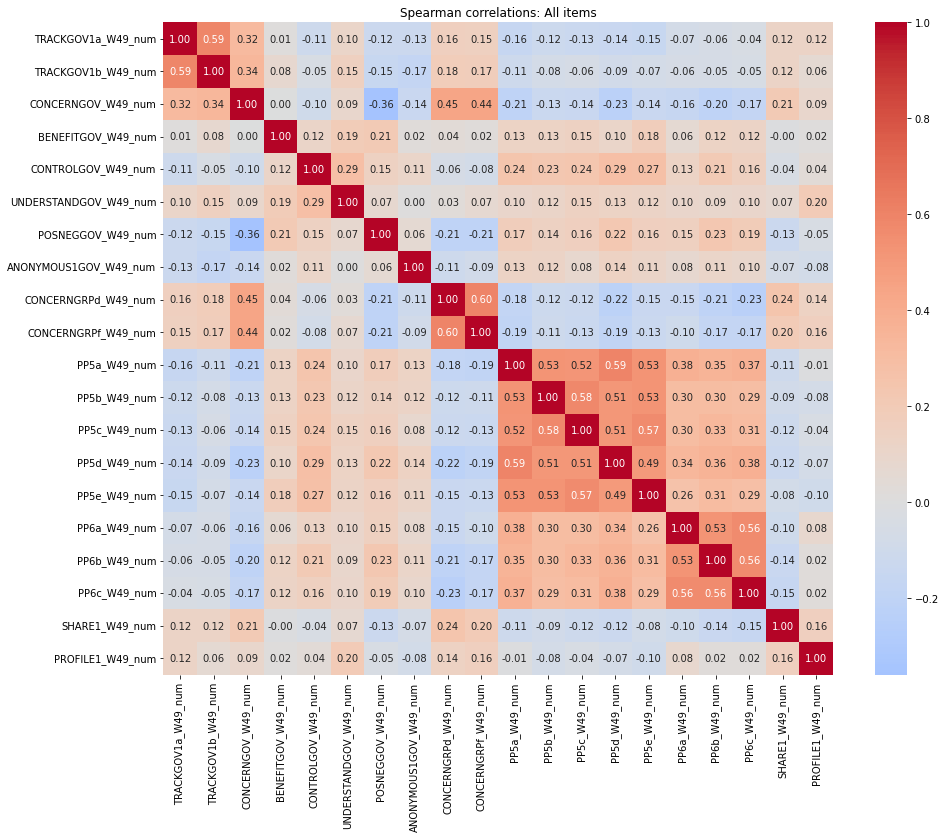

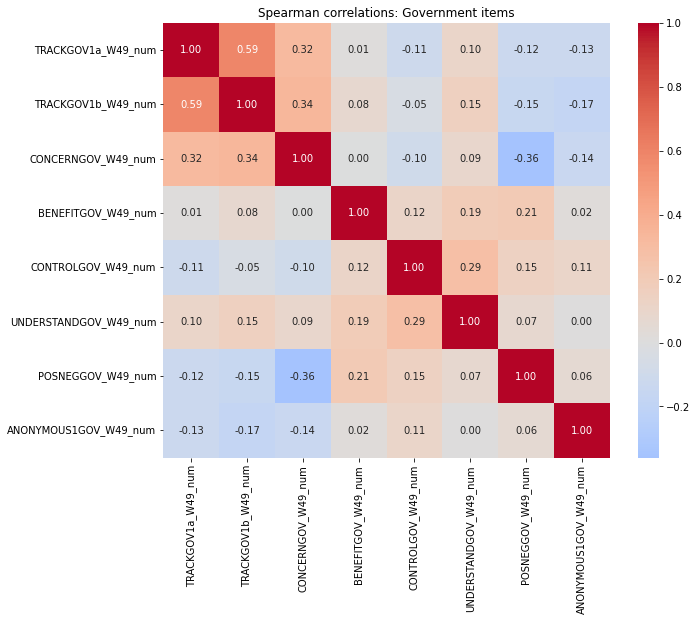

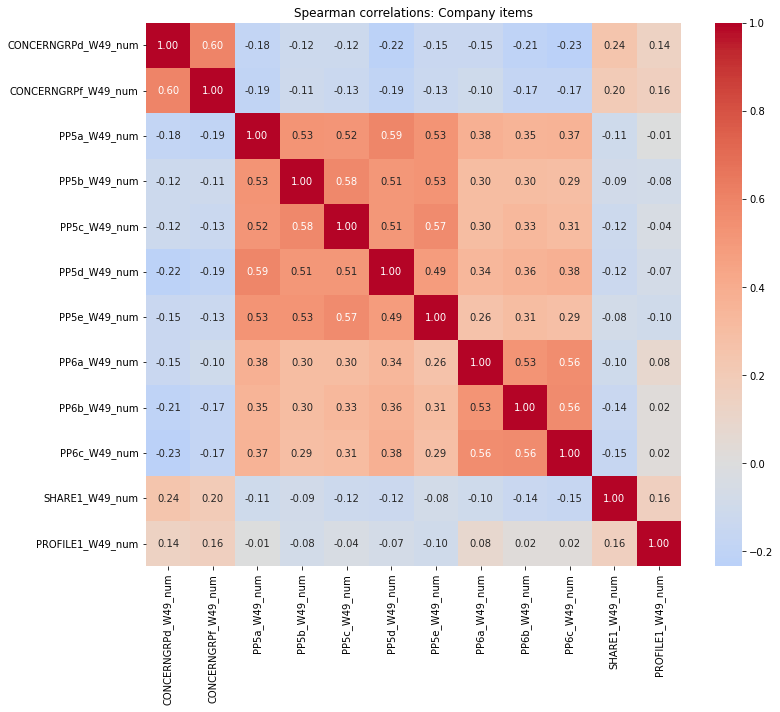

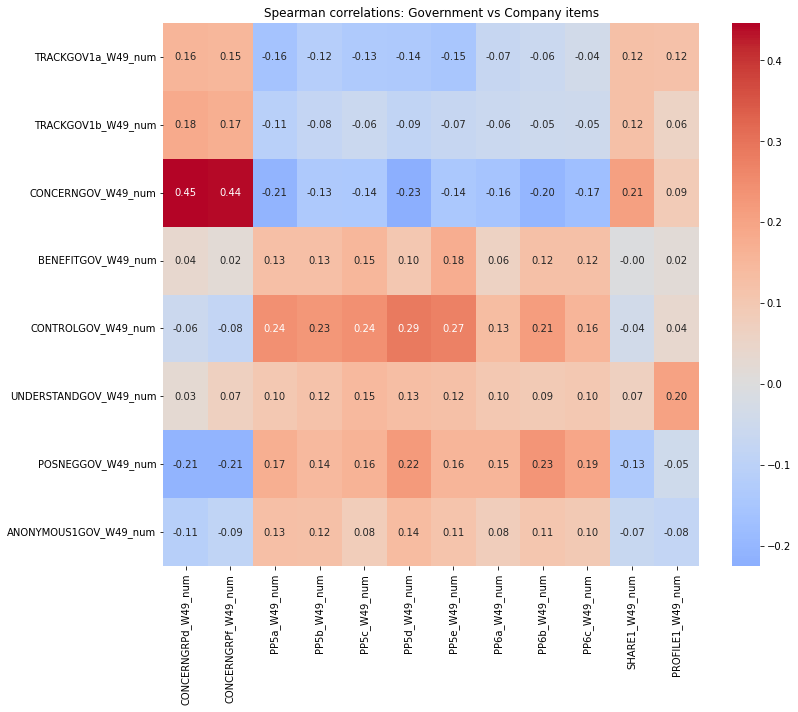

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. All items vs all items ---
plt.figure(figsize=(15,12))
sns.heatmap(corr_block_all, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Spearman correlations: All items")
plt.show()

# --- 2. Government vs government ---
plt.figure(figsize=(10,8))
sns.heatmap(corr_block_gov_gov, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Spearman correlations: Government items")
plt.show()

# --- 3. Company vs company ---
plt.figure(figsize=(12,10))
sns.heatmap(corr_block_com_com, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Spearman correlations: Company items")
plt.show()

# --- 4. Government vs company ---
plt.figure(figsize=(12,10))
sns.heatmap(corr_block_gov_com, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Spearman correlations: Government vs Company items")
plt.show()


In [65]:

categories = {
    'gov_benefit': ['BENEFITGOV_W49_num'], #'POSNEGGOV_W49_num'],  # Low = more perceived benefit, high = less percieved benefit
    'gov_concern': ['CONCERNGOV_W49_num'], # Low = more concern about government collection, high = less concern about government collection
    'gov_control': ['CONTROLGOV_W49_num'], # Low = more control over collected data, high = no control over collected data
    'gov_understanding': ['UNDERSTANDGOV_W49_num'], # Low = great understanding, high = no understanding
    'gov_tracking': ['TRACKGOV1a_W49_num','TRACKGOV1b_W49_num'], # Low = everything is tracked by government, high = nothing is tracked by governemnent

    'com_trust': ['PP5a_W49_num','PP5b_W49_num','PP5c_W49_num','PP5d_W49_num','PP5e_W49_num'], # Low = more trust/confidence, high = not confident/trust
    'com_comfort': ['PP6a_W49_num','PP6b_W49_num','PP6c_W49_num'], # Low = very comfortable with usage of data, high = not comfortable at all
    'com_concern': ['CONCERNGRPd_W49_num','CONCERNGRPf_W49_num', "SHARE1_W49_num"] # Low = concerned about data, high = not concerned at all
}


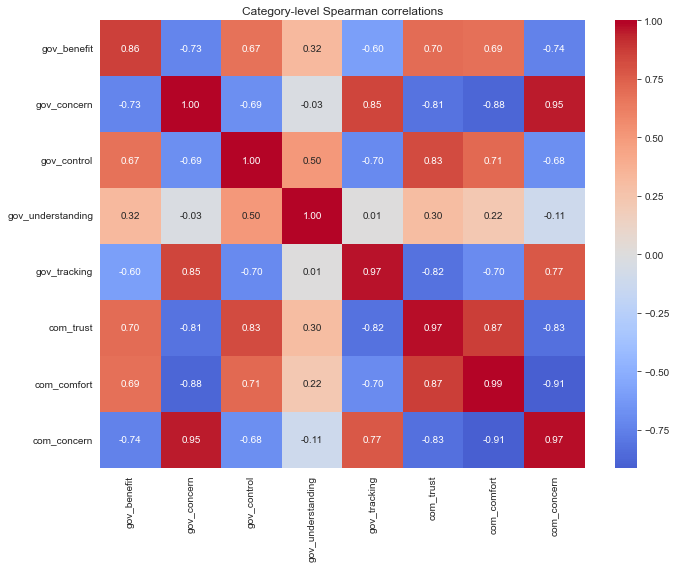

In [66]:
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure all items are numeric
all_items = sum(categories.values(), [])
corr[all_items] = corr[all_items].apply(pd.to_numeric, errors='coerce')

# Initialize empty category-level correlation matrix
category_names = list(categories.keys())
category_matrix = pd.DataFrame(index=category_names, columns=category_names, dtype=float)

# Compute average Spearman correlation between each pair of categories
for cat1 in category_names:
    for cat2 in category_names:
        items1 = categories[cat1]
        items2 = categories[cat2]
        rhos = []
        for i in items1:
            for j in items2:
                valid = corr[[i, j]].dropna()
                if len(valid) > 2:
                    rho, _ = spearmanr(valid[i], valid[j])
                    # Sometimes rho is a 2×2 matrix → extract scalar
                    if isinstance(rho, (np.ndarray, list)):
                        try:
                            rho = rho[0, 1]
                        except Exception:
                            rho = np.nan
                    # Append only valid scalar values
                    if isinstance(rho, (int, float, np.floating)) and not np.isnan(rho):
                        rhos.append(rho)
        # Take mean of all pairwise correlations
        category_matrix.loc[cat1, cat2] = np.mean(rhos) if len(rhos) > 0 else np.nan

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(category_matrix.astype(float), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Category-level Spearman correlations")
plt.tight_layout()
plt.show()
